## 1. Importación de Librerías y Configuración

In [1]:
import numpy as np
import pandas as pd
import os
import pathlib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow Version: {tf.__version__}')
print(f'Num GPUs Available: {len(tf.config.list_physical_devices("GPU"))}')

2026-04-06 11:09:45.516685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775473785.681949      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775473785.729066      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775473786.094650      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775473786.094702      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775473786.094705      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Num GPUs Available: 2


## 2. Definición del Dataset

In [2]:
# Ajustar ruta según entorno (Kaggle o local)
data_dir = pathlib.Path('/kaggle/input/datasets/ubitquitin/geolocation-geoguessr-images-50k')
#current_dir = pathlib.Path(os.getcwd())
#data_dir = current_dir / 'data' / 'compressed_dataset' # Ruta local por defecto

print(f"Buscando imágenes en: {data_dir}")

filepaths = list(data_dir.glob(r'**/*.jpg'))
labels = [os.path.split(os.path.split(x)[0])[1] for x in filepaths]

df = pd.DataFrame({'Filepath': [str(x) for x in filepaths], 'Label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Filtrar países con pocas imágenes (Mínimo 50 para buena generalización)
MIN_IMAGENES = 50
num_fotos_por_pais = df['Label'].value_counts()
paises_validos = num_fotos_por_pais[num_fotos_por_pais >= MIN_IMAGENES].index
df_filtrado = df[df['Label'].isin(paises_validos)].copy()

print(f"Hemos mantenido {len(paises_validos)} países de {len(num_fotos_por_pais)}")
print(f"Dataset filtrado: {len(df_filtrado)} imágenes")

train_df, val_df = train_test_split(
    df_filtrado,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df_filtrado['Label']
)

print(f"Imágenes de Entrenamiento: {len(train_df)}")
print(f"Imágenes de Validación: {len(val_df)}")

Buscando imágenes en: /kaggle/input/datasets/ubitquitin/geolocation-geoguessr-images-50k
Hemos mantenido 76 países de 124
Dataset filtrado: 49422 imágenes
Imágenes de Entrenamiento: 39537
Imágenes de Validación: 9885


## 3. Data Generators

In [3]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

datagen = ImageDataGenerator(rescale=1./255)

train_images = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_images = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

num_classes = len(train_images.class_indices)

# Calcular los pesos de clase para manejar el desbalanceo
train_labels = train_images.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))

Found 39537 validated image filenames belonging to 76 classes.
Found 9885 validated image filenames belonging to 76 classes.


## 4. Construcción de la CNN Personalizada

In [4]:
from tensorflow.keras.regularizers import l2

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False, kernel_regularizer=l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=False, kernel_regularizer=l2(1e-5))(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_custom_cnn(num_classes):
    inputs = keras.Input(shape=(224, 224, 3))
    
    # --- 1. Data Augmentation --- 
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.2)(x)
#     x = layers.RandomTranslation(0.1, 0.1)(x)
    x = layers.RandomContrast(0.25)(x)
    
    # --- Entrada inicial ---
    x = layers.Conv2D(32, (7, 7), strides=2, padding='same', use_bias=False, kernel_regularizer=l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same')(x)
    
    # --- Bloques Residuales ---
    x = residual_block(x, filters=64, stride=1)
    x = residual_block(x, filters=64, stride=1)
    
    x = residual_block(x, filters=128, stride=2)
    x = residual_block(x, filters=128, stride=1)
    
    x = residual_block(x, filters=256, stride=2)
    x = residual_block(x, filters=256, stride=1)
    
    # --- 6. Cabeza Clasificadora ---
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

model = build_custom_cnn(num_classes)
model.summary()


I0000 00:00:1775473873.895491      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775473873.901447      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      4,704 │ random_contrast[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 2,938,924 (11.21 MB)

 Trainable params: 2,933,356 (11.19 MB)

 Non-trainable params: 5,568 (21.75 KB)

## 5. Compilación y Configuración de Callbacks

In [5]:
from tensorflow.keras.optimizers.schedules import CosineDecay

EPOCHS = 40
initial_learning_rate = 0.0001
decay_steps = int((39537 / 32) * EPOCHS) # approx steps per epoch * epochs

lr_schedule = CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    alpha=0.01 # minimum learning rate will be 1% of initial
)

opt = keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

callbacks_list = [
    callbacks.ModelCheckpoint(
        '/kaggle/working/best_custom_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]


## 6. Entrenamiento

In [6]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1775473888.544533     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


1236/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.0202 - loss: 4.7451 - top_5_accuracy: 0.0881
Epoch 1: val_accuracy improved from -inf to 0.03500, saving model to /kaggle/working/best_custom_cnn.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 528s 416ms/step - accuracy: 0.0202 - loss: 4.7449 - top_5_accuracy: 0.0881 - val_accuracy: 0.0350 - val_loss: 4.2917 - val_top_5_accuracy: 0.1200
Epoch 2/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.0318 - loss: 4.2783 - top_5_accuracy: 0.1207
Epoch 2: val_accuracy did not improve from 0.03500
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 335s 271ms/step - accuracy: 0.0318 - loss: 4.2783 - top_5_accuracy: 0.1207 - val_accuracy: 0.0309 - val_loss: 4.7528 - val_top_5_accuracy: 0.1145
Epoch 3/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.0408 - loss: 4.1056 - top_5_accuracy: 0.1506
Epoch 3: val_accuracy improved from 0.03500 to 0.05159, saving model to /kaggle/working/best_custom_cnn.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 327s 264ms/st

## 7. Gráficas de Rendimiento

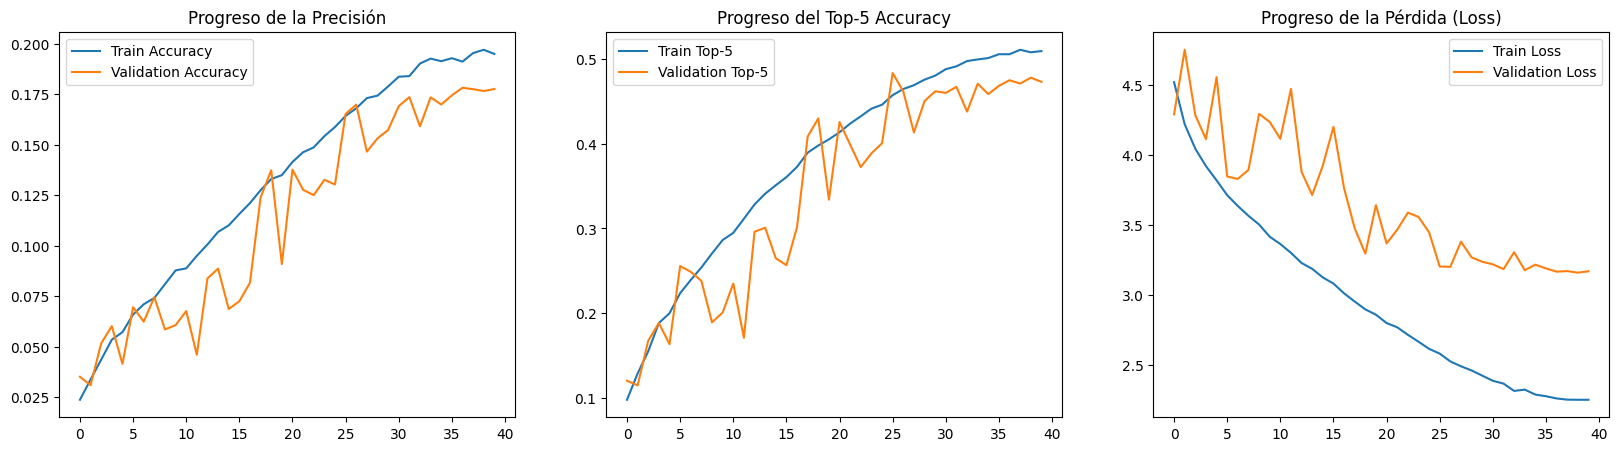

In [7]:
plt.figure(figsize=(20, 5))

# Precisión
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Progreso de la Precisión')

# Top-5 Precisión
plt.subplot(1, 3, 2)
if 'top_5_accuracy' in history.history:
    plt.plot(history.history['top_5_accuracy'], label='Train Top-5')
    plt.plot(history.history['val_top_5_accuracy'], label='Validation Top-5')
    plt.legend()
    plt.title('Progreso del Top-5 Accuracy')

# Pérdida / Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Progreso de la Pérdida (Loss)')

plt.show()


## 8. Verificación Visual de Predicciones

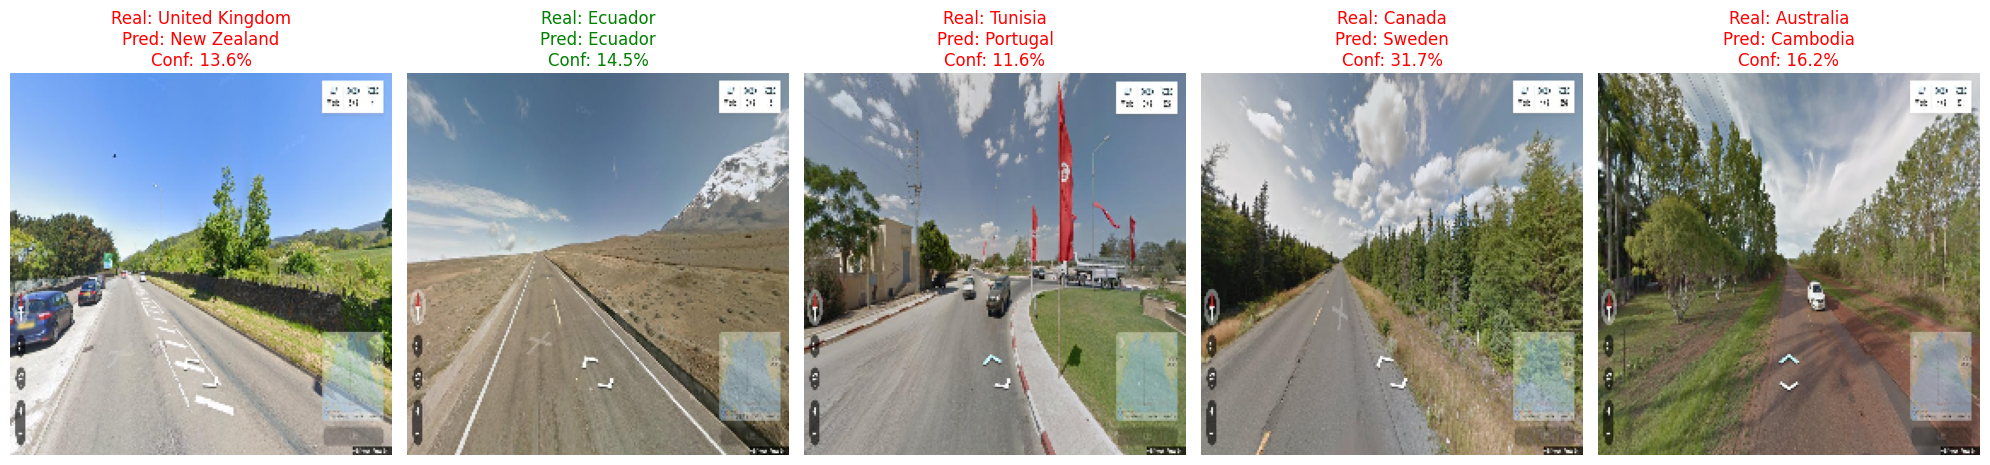

In [10]:
labels_map = {v: k for k, v in train_images.class_indices.items()}

# Obtenemos lote aleatorio de validación
sample_images, sample_labels = next(val_images)
random_indices = np.random.choice(range(len(sample_images)), size=5, replace=False)

plt.figure(figsize=(20, 10))
for i, idx in enumerate(random_indices):
    image = sample_images[idx]
    true_label_idx = np.argmax(sample_labels[idx])
    true_country = labels_map[true_label_idx]
    
    prediction_scores = model.predict(np.expand_dims(image, axis=0), verbose=0)
    predicted_label_idx = np.argmax(prediction_scores)
    predicted_country = labels_map[predicted_label_idx]
    confidence = np.max(prediction_scores) * 100
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    color = 'green' if true_country == predicted_country else 'red'
    plt.title(f"Real: {true_country}\nPred: {predicted_country}\nConf: {confidence:.1f}%", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()